In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import pyarrow.parquet as pq



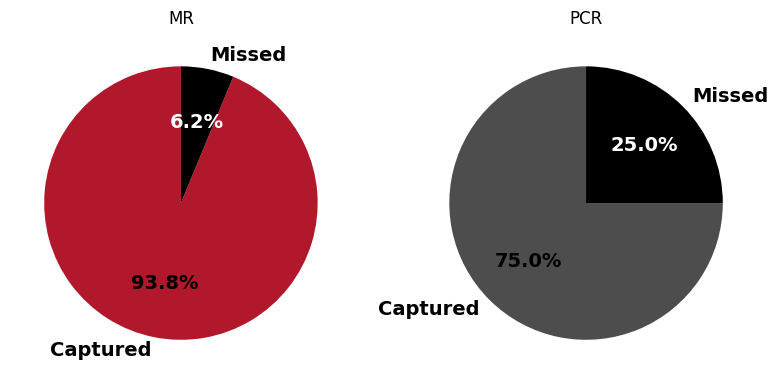

In [2]:
CR = pd.DataFrame()
MR = [15, 1]
PCR = [12, 4]
CR["MR"] = MR
CR["PCR"] = PCR
CR["Hit"] = ["Captured", "Missed"]

missed_color = "black"
captured_color_MR = '#b2182b'   # red-orange
captured_color_PCR = '#4d4d4d'  # teal

def custom_autopct(values):
    """Returns a function for coloring missed % white."""
    def inner_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        if val == values[1]:  # missed slice (index 1)
            return f'%\n{pct:.1f}'  # placeholder, will recolor later
        else:
            return f'{pct:.1f}%'
    return inner_autopct

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# MR pie chart
wedges, texts, autotexts = axes[0].pie(
    CR["MR"],
    labels=CR["Hit"],
    colors=[captured_color_MR, missed_color],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
axes[0].set_title("MR")

# Set missed % text to white
autotexts[1].set_color('white')

# PCR pie chart
wedges, texts, autotexts = axes[1].pie(
    CR["PCR"],
    labels=CR["Hit"],
    colors=[captured_color_PCR, missed_color],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
axes[1].set_title("PCR")

# Set missed % text to white
autotexts[1].set_color('white')

plt.tight_layout()
plt.savefig("Capture_rate.png", dpi = 600)
plt.savefig("Capture_rate.svg")
plt.show()


In [3]:
KASPAR =  pq.read_table(r"data/Report_nonMBR.parquet")
KASPAR = KASPAR.to_pandas()
KASPAR_stats = pd.read_csv(r"data/Report_nonMBR.stats.tsv", sep = "\t")

In [4]:
annotation= pd.read_csv(r"data/MR_SP2_annotation.txt", sep = "\t")
annotation["Experiment"] = annotation["Prep"] + "_" + annotation["Cells"].astype(str) + "_" + annotation["Replicate"].astype(str)
annotation["Condition"] = annotation["Prep"] + "_" + annotation["Cells"].astype(str)

In [5]:
KASPAR = pd.merge(KASPAR, annotation, on = "Run", how = "inner")

KASPAR["Log2_ProteinIntensity"] = np.log2(KASPAR["PG.MaxLFQ"])
KASPAR["Log2_PeptideIntensity"] = np.log2(KASPAR["Precursor.Quantity"])
KASPAR["MBR_condition"] = "no_MBR"
KASPAR["MBR_condition"] = "no_MBR"

D:\tools\Miniconda3\envs\Maxi_DataAnalysis\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
KASPAR_MBR_data = []

for i in ["MBR_Int_1.5", "MBR_Int_5.5", "MBR_Int22", "MBR_PCR_1.5", "MBR_PCR_5.5", "MBR_PCR_22"]:
    path = fr"data\MR_SP2_withMBR\{i}\{i}.parquet"
    KASPAR_MBR_data.append(pq.read_table(path).to_pandas())
KASPAR_MBR = pd.concat(KASPAR_MBR_data)
KASPAR_MBR["MBR_condition"] = "MBR"
KASPAR_MBR = pd.merge(KASPAR_MBR, annotation, on = "Run", how = "inner")

KASPAR_MBR["Log2_ProteinIntensity"] = np.log2(KASPAR_MBR["PG.MaxLFQ"])
KASPAR_MBR["Log2_PeptideIntensity"] = np.log2(KASPAR_MBR["Precursor.Quantity"])

D:\tools\Miniconda3\envs\Maxi_DataAnalysis\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
order =   ['PCR_22.0_R1', 'PCR_22.0_R2', 'PCR_22.0_R3', 'PCR_22.0_R4', 'PCR_22.0_R5','PCR_22.0_R6',  'PCR_22.0_R7', 'PCR_22.0_R8',
           'Int_22.0_R1', 'Int_22.0_R2', 'Int_22.0_R3', 'Int_22.0_R4', 'Int_22.0_R5','Int_22.0_R6', 'Int_22.0_R7','Int_22.0_R8','Int_22.0_R9', 'Int_22.0_R10','Int_22.0_R11',
            'PCR_5.5_R3', 'PCR_5.5_R5','PCR_5.5_R4','PCR_5.5_R1','PCR_5.5_R2',
           'Int_5.5_R2', 'Int_5.5_R4','Int_5.5_R1', 'Int_5.5_R5','Int_5.5_R3',
        'PCR_1.5_R4', 'PCR_1.5_R1',   'PCR_1.5_R5', 'PCR_1.5_R2', 'PCR_1.5_R3',
        'Int_1.5_R4', 'Int_1.5_R3', 'Int_1.5_R5','Int_1.5_R1', 'Int_1.5_R2']

condition_order = ["PCR_22.0","Int_22.0", 'PCR_5.5', 'Int_5.5',  'PCR_1.5', 'Int_1.5']

In [8]:


ID_summary_MBR = pd.DataFrame()
ProteinIDs = []
PeptideIDs = []
ModifiedPeptides = []

for i in KASPAR_MBR["Experiment"].unique():
    a =  KASPAR_MBR[KASPAR_MBR["Experiment"] == i]
    ProteinIDs.append(len(a["Protein.Group"].unique()))
    PeptideIDs.append(len(a["Stripped.Sequence"].unique()))
    ModifiedPeptides.append(len(a["Modified.Sequence"].unique()))
ID_summary_MBR["Experiment"] = KASPAR_MBR["Experiment"].unique()
ID_summary_MBR["Protein_IDs"] = ProteinIDs
ID_summary_MBR["Peptide_IDs"] = PeptideIDs
ID_summary_MBR["ModifiedPeptides_IDs"] = ModifiedPeptides



ID_summary = pd.DataFrame()
ProteinIDs = []
PeptideIDs = []
ModifiedPeptides = []

for i in KASPAR["Experiment"].unique():
    a =  KASPAR[KASPAR["Experiment"] == i]
    ProteinIDs.append(len(a["Protein.Group"].unique()))
    PeptideIDs.append(len(a["Stripped.Sequence"].unique()))
    ModifiedPeptides.append(len(a["Modified.Sequence"].unique()))
ID_summary["Experiment"] = KASPAR["Experiment"].unique()
ID_summary["Protein_IDs"] = ProteinIDs
ID_summary["Peptide_IDs"] = PeptideIDs
ID_summary["ModifiedPeptides_IDs"] = ModifiedPeptides



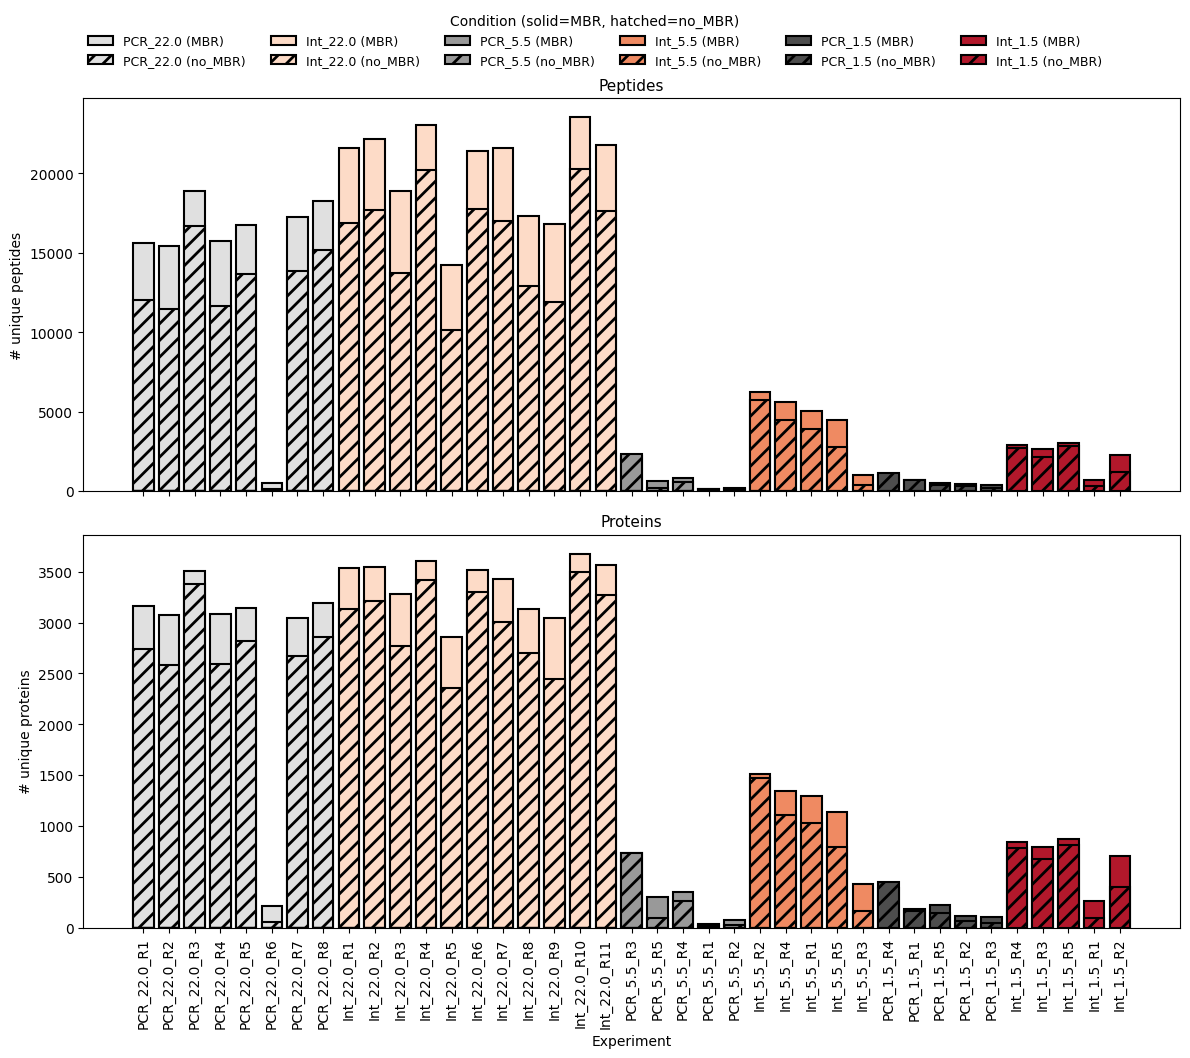

In [9]:
from matplotlib.patches import Patch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Custom order and palette ---
condition_order = ["PCR_22.0", "Int_22.0", "PCR_5.5", "Int_5.5", "PCR_1.5", "Int_1.5"]
costume_palette = {
    "PCR_22.0": '#e0e0e0',
    "Int_22.0": '#fddbc7',
    "PCR_5.5": '#999999',
    "Int_5.5": '#ef8a62',
    "PCR_1.5": '#4d4d4d',
    "Int_1.5": '#b2182b',
}

# --- Concatenate MBR and no_MBR data (UNCHANGED) ---
summary_list = []
for df, mbr_cond in [(KASPAR, "no_MBR"), (KASPAR_MBR, "MBR")]:
    temp = df.groupby(["Experiment", "Condition"]).agg(
        Protein_IDs=("Protein.Group", "nunique"),
        Peptide_IDs=("Stripped.Sequence", "nunique"),
        ModifiedPeptides_IDs=("Modified.Sequence", "nunique")
    ).reset_index()
    temp["MBR_Condition"] = mbr_cond
    summary_list.append(temp)

Summary_File = pd.concat(summary_list, ignore_index=True)

# --- Define experiment order (UNCHANGED) ---
order = ['PCR_22.0_R1', 'PCR_22.0_R2', 'PCR_22.0_R3', 'PCR_22.0_R4', 'PCR_22.0_R5','PCR_22.0_R6',  'PCR_22.0_R7', 'PCR_22.0_R8',
         'Int_22.0_R1', 'Int_22.0_R2', 'Int_22.0_R3', 'Int_22.0_R4', 'Int_22.0_R5','Int_22.0_R6', 'Int_22.0_R7','Int_22.0_R8','Int_22.0_R9', 'Int_22.0_R10','Int_22.0_R11',
         'PCR_5.5_R3', 'PCR_5.5_R5','PCR_5.5_R4','PCR_5.5_R1','PCR_5.5_R2',
         'Int_5.5_R2', 'Int_5.5_R4','Int_5.5_R1', 'Int_5.5_R5','Int_5.5_R3',
         'PCR_1.5_R4', 'PCR_1.5_R1',   'PCR_1.5_R5', 'PCR_1.5_R2', 'PCR_1.5_R3',
         'Int_1.5_R4', 'Int_1.5_R3', 'Int_1.5_R5','Int_1.5_R1', 'Int_1.5_R2']

# Hatch settings
plt.rcParams['hatch.color'] = 'black'
plt.rcParams['hatch.linewidth'] = 2.0

# --- Create figure (TALLER for legend space) ---
fig, axes = plt.subplots(2, 1, figsize=(12, 10))  # Increased height

# --- Helper function (UNCHANGED) ---
def plot_stacked(ax, y_col, title, ylabel, show_xlabel=False):
    mbr_data = Summary_File[Summary_File["MBR_Condition"] == "MBR"][["Experiment", "Condition", y_col]]
    no_mbr_data = Summary_File[Summary_File["MBR_Condition"] == "no_MBR"][["Experiment", "Condition", y_col]]

    x_pos = np.arange(len(order))
    width = 0.8

    # MBR: TALLER solid bars
    for i, cond in enumerate(condition_order):
        heights = mbr_data[mbr_data["Condition"] == cond].set_index("Experiment").reindex(order)[y_col].fillna(0).values
        bars_mbr = ax.bar(x_pos, heights, width, color=costume_palette[cond], alpha=1.0,
                         edgecolor='black', linewidth=1.5)
        for bar in bars_mbr:
            bar.set_hatch('')
            bar.set_zorder(2)
            bar.set_rasterized(True)

    # no_MBR: SHORTER hatched overlay
    for i, cond in enumerate(condition_order):
        heights = no_mbr_data[no_mbr_data["Condition"] == cond].set_index("Experiment").reindex(order)[y_col].fillna(0).values
        bars_no_mbr = ax.bar(x_pos, heights, width, bottom=0, color=costume_palette[cond], alpha=1.0,
                            edgecolor='black', linewidth=1.5)
        for bar in bars_no_mbr:
            bar.set_hatch('//')
            bar.set_zorder(3)
            bar.set_rasterized(True)

    # Formatting
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_pos)
    if show_xlabel:
        ax.set_xticklabels(order, rotation=90)
        ax.set_xlabel("Experiment")
    else:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    if hasattr(ax, 'legend_') and ax.legend_ is not None:
        ax.legend_.remove()

# --- Plot panels ---
plot_stacked(axes[0], "Peptide_IDs", "Peptides", "# unique peptides", show_xlabel=False)
plot_stacked(axes[1], "Protein_IDs", "Proteins", "# unique proteins", show_xlabel=True)

# --- Legend (MAX DISTANCE above) ---
legend_patches = []
for cond in condition_order:
    legend_patches.append(Patch(facecolor=costume_palette[cond], alpha=1.0,
                                edgecolor="black", linewidth=1.5,
                                label=f"{cond} (MBR)"))
    legend_patches.append(Patch(facecolor=costume_palette[cond], alpha=1.0,
                                edgecolor="black", linewidth=1.5, hatch='//',
                                label=f"{cond} (no_MBR)"))

fig.legend(handles=legend_patches, loc="upper center",
           bbox_to_anchor=(0.5, 1.06),
           ncol=6, frameon=False,
           title="Condition (solid=MBR, hatched=no_MBR)",
           fontsize=9)  # Smaller font


plt.subplots_adjust(top=0.88)  # MAX space above plots
plt.tight_layout()
plt.savefig("Stacked_Run_summary_MBR_vs_noMBR_byExperiment.svg", dpi=600, bbox_inches='tight')
plt.savefig("Stacked_Run_summary_MBR_vs_noMBR_byExperiment.png", dpi=600, bbox_inches='tight')
plt.show()


In [10]:
print(KASPAR_MBR[KASPAR_MBR["Experiment"].str.contains("PCR_22.0_R6")]["Stripped.Sequence"].nunique())
print(KASPAR_MBR[KASPAR_MBR["Experiment"].str.contains("PCR_22.0_R6")]["Protein.Group"].nunique())


515
219


In [11]:
KASPAR = KASPAR[KASPAR["Experiment"] != "PCR_22.0_R6"]
KASPAR_MBR = KASPAR_MBR[KASPAR_MBR["Experiment"] != "PCR_22.0_R6"]

In [12]:
ID_summary["MBR_Condition"] =  "no_MBR"
ID_summary_MBR["MBR_Condition"] =  "MBR"
Summary_File = pd.concat([ID_summary, ID_summary_MBR])
Summary_File = pd.merge(Summary_File, annotation[["Experiment", "Condition"]], on = "Experiment")

Summary_File = Summary_File[Summary_File["Experiment"] != "PCR_22.0_R6"]

In [13]:
Summary_File.groupby(["Condition","MBR_Condition"])[["Protein_IDs", "Peptide_IDs", "ModifiedPeptides_IDs"]].mean()

Protein_IDs   Peptide_IDs  ModifiedPeptides_IDs
Condition MBR_Condition                                                 
Int_1.5   MBR             695.600000   2320.400000           2320.400000
          no_MBR          557.000000   1841.600000           1841.600000
Int_22.0  MBR            3381.363636  20229.181818          20229.181818
          no_MBR         3009.363636  16020.727273          16020.727273
Int_5.5   MBR            1145.200000   4495.800000           4495.800000
          no_MBR          914.800000   3467.600000           3467.600000
PCR_1.5   MBR             206.200000    601.600000            601.600000
          no_MBR          176.200000    541.000000            541.000000
PCR_22.0  MBR            3174.142857  16852.857143          16852.857143
          no_MBR         2806.000000  13514.142857          13514.142857
PCR_5.5   MBR             302.000000    801.200000            801.200000
          no_MBR          231.200000    685.600000            685.600000

In [14]:
Summary_File.groupby(["Condition","MBR_Condition"])[["Protein_IDs", "Peptide_IDs", "ModifiedPeptides_IDs"]].std()

Protein_IDs  Peptide_IDs  ModifiedPeptides_IDs
Condition MBR_Condition                                                
Int_1.5   MBR             251.225596   946.170598            946.170598
          no_MBR          302.151452  1072.420300           1072.420300
Int_22.0  MBR             265.052173  2969.958781           2969.958781
          no_MBR          390.302517  3349.430283           3349.430283
Int_5.5   MBR             420.443456  2040.264248           2040.264248
          no_MBR          483.396007  2017.641024           2017.641024
PCR_1.5   MBR             114.523797   247.659645            247.659645
          no_MBR          163.020551   380.907469            380.907469
PCR_22.0  MBR             156.308913  1357.207602           1357.207602
          no_MBR          274.204911  1956.408395           1956.408395
PCR_5.5   MBR             281.555501   849.750375            849.750375
          no_MBR          300.808411   940.622294            940.622294

In [15]:
from scipy.stats import mannwhitneyu

# Define condition pairs
condition_pairs = [
    ("PCR_1.5", "Int_1.5"),
    ("PCR_5.5", "Int_5.5"),
    ("PCR_22.0", "Int_22.0")
]

# Function to convert p-value to stars with 3 decimals
def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return f"p = {p:.3f}"

# Filter MBR data
MBR_data = Summary_File[Summary_File["MBR_Condition"] == "MBR"]

# Store test results
test_results = {"proteins": [], "peptides": []}

# Run Mann–Whitney U tests on MBR data only
for cond1, cond2 in condition_pairs:
    prot1 = MBR_data[MBR_data["Condition"] == cond1]["Protein_IDs"]
    prot2 = MBR_data[MBR_data["Condition"] == cond2]["Protein_IDs"]
    pep1 = MBR_data[MBR_data["Condition"] == cond1]["Peptide_IDs"]
    pep2 = MBR_data[MBR_data["Condition"] == cond2]["Peptide_IDs"]

    _, p_prot = mannwhitneyu(prot1, prot2, alternative='two-sided')
    _, p_pep = mannwhitneyu(pep1, pep2, alternative='two-sided')

    test_results["proteins"].append(((cond1, cond2), p_prot))
    test_results["peptides"].append(((cond1, cond2), p_pep))

# ---- NEW: Print results in a readable table ----
prot_df = pd.DataFrame([
    {"Comparison": f"{c1} vs {c2}", "Protein_pval": p, "Protein_signif": get_star(p)}
    for (c1, c2), p in test_results["proteins"]
])

pep_df = pd.DataFrame([
    {"Comparison": f"{c1} vs {c2}", "Peptide_pval": p, "Peptide_signif": get_star(p)}
    for (c1, c2), p in test_results["peptides"]
])

print("\nMann–Whitney U test results (Proteins):")
print(prot_df.to_string(index=False))

print("\nMann–Whitney U test results (Peptides):")
print(pep_df.to_string(index=False))



Mann–Whitney U test results (Proteins):
          Comparison  Protein_pval Protein_signif
  PCR_1.5 vs Int_1.5      0.015873              *
  PCR_5.5 vs Int_5.5      0.015873              *
PCR_22.0 vs Int_22.0      0.104198      p = 0.104

Mann–Whitney U test results (Peptides):
          Comparison  Peptide_pval Peptide_signif
  PCR_1.5 vs Int_1.5      0.015873              *
  PCR_5.5 vs Int_5.5      0.015873              *
PCR_22.0 vs Int_22.0      0.015397              *


In [16]:
# Filter non-MBR data
non_MBR = Summary_File[Summary_File["MBR_Condition"] != "MBR"]

# Aggregate mean and SEM for Protein_IDs and Peptide_IDs
summary_table = non_MBR.groupby("Condition").agg(
    Protein_Mean=("Protein_IDs", "mean"),
    Protein_SEM=("Protein_IDs", "sem"),
    Peptide_Mean=("Peptide_IDs", "mean"),
    Peptide_SEM=("Peptide_IDs", "sem")
).reset_index()

# Optional: create "Mean ± SEM" columns for reporting
summary_table["Protein"] = summary_table.apply(
    lambda row: f"{row['Protein_Mean']:.1f} ± {row['Protein_SEM']:.1f}", axis=1)
summary_table["Peptide"] = summary_table.apply(
    lambda row: f"{row['Peptide_Mean']:.1f} ± {row['Peptide_SEM']:.1f}", axis=1)

# Reorder columns for reporting
summary_table = summary_table[["Condition", "Protein", "Peptide"]]

print(summary_table)


  Condition         Protein           Peptide
0   Int_1.5   557.0 ± 135.1    1841.6 ± 479.6
1  Int_22.0  3009.4 ± 117.7  16020.7 ± 1009.9
2   Int_5.5   914.8 ± 216.2    3467.6 ± 902.3
3   PCR_1.5    176.2 ± 72.9     541.0 ± 170.3
4  PCR_22.0  2806.0 ± 103.6   13514.1 ± 739.5
5   PCR_5.5   231.2 ± 134.5     685.6 ± 420.7


In [17]:


# Filter non-MBR data
non_MBR = Summary_File[Summary_File["MBR_Condition"] == "MBR"]

# Aggregate mean and SEM for Protein_IDs and Peptide_IDs
summary_table = non_MBR.groupby("Condition").agg(
    Protein_Mean=("Protein_IDs", "mean"),
    Protein_SEM=("Protein_IDs", "sem"),
    Peptide_Mean=("Peptide_IDs", "mean"),
    Peptide_SEM=("Peptide_IDs", "sem")
).reset_index()

# Optional: create "Mean ± SEM" columns for reporting
summary_table["Protein"] = summary_table.apply(
    lambda row: f"{row['Protein_Mean']:.1f} ± {row['Protein_SEM']:.1f}", axis=1)
summary_table["Peptide"] = summary_table.apply(
    lambda row: f"{row['Peptide_Mean']:.1f} ± {row['Peptide_SEM']:.1f}", axis=1)

# Reorder columns for reporting
summary_table = summary_table[["Condition", "Protein", "Peptide"]]

print(summary_table)


  Condition         Protein          Peptide
0   Int_1.5   695.6 ± 112.4   2320.4 ± 423.1
1  Int_22.0   3381.4 ± 79.9  20229.2 ± 895.5
2   Int_5.5  1145.2 ± 188.0   4495.8 ± 912.4
3   PCR_1.5    206.2 ± 51.2    601.6 ± 110.8
4  PCR_22.0   3174.1 ± 59.1  16852.9 ± 513.0
5   PCR_5.5   302.0 ± 125.9    801.2 ± 380.0


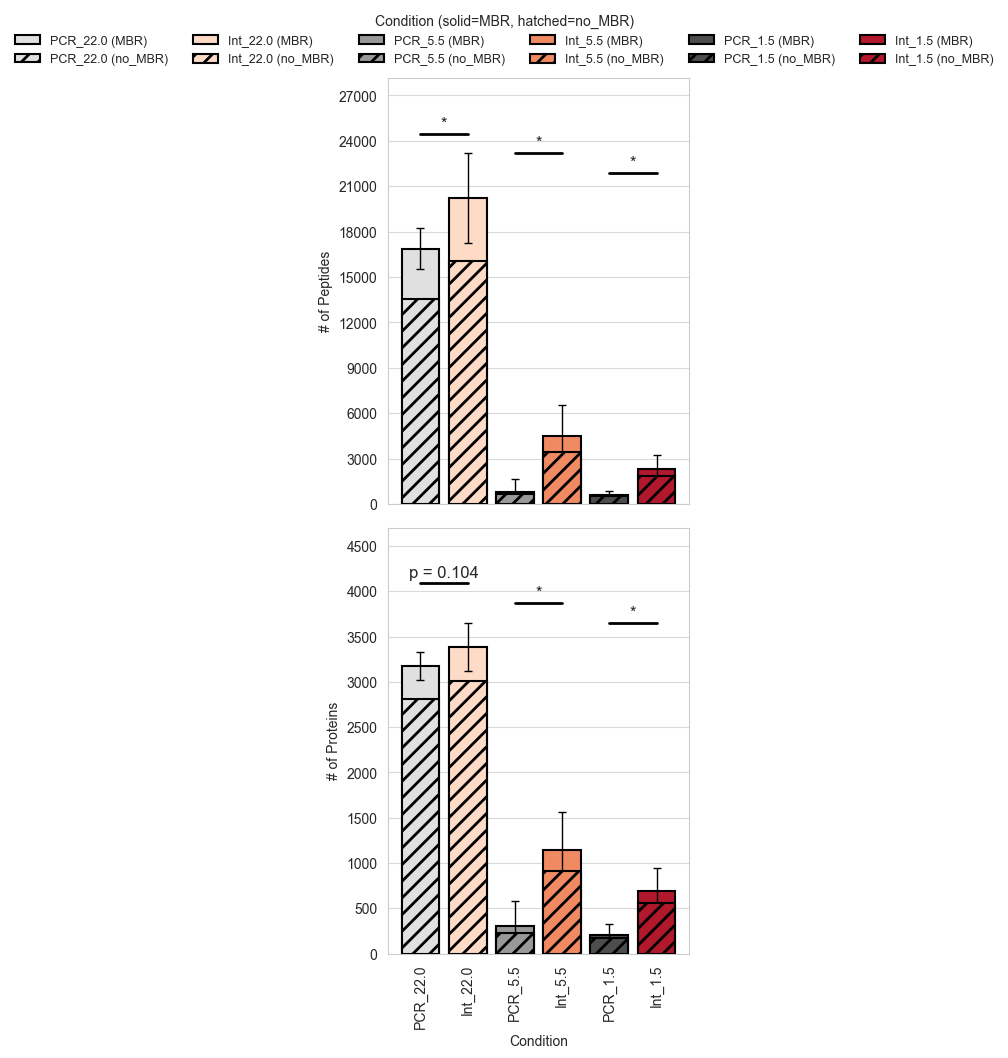

In [18]:

# Seaborn-like base style
sns.set_style(
    "whitegrid",
    {
        "axes.grid": True,
        "grid.color": "0.85",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
    },
)

condition_order = ["PCR_22.0", "Int_22.0", "PCR_5.5", "Int_5.5", "PCR_1.5", "Int_1.5"]
costume_palette = {
    "PCR_22.0": '#e0e0e0',
    "Int_22.0": '#fddbc7',
    "PCR_5.5": '#999999',
    "Int_5.5": '#ef8a62',
    "PCR_1.5": '#4d4d4d',
    "Int_1.5": '#b2182b',
}

condition_pairs = [("PCR_1.5", "Int_1.5"), ("PCR_5.5", "Int_5.5"), ("PCR_22.0", "Int_22.0")]

def get_star(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return f"p = {p:.3f}"

# Data prep
MBR_data = Summary_File[Summary_File["MBR_Condition"] == "MBR"]
no_MBR_data = Summary_File[Summary_File["MBR_Condition"] == "no_MBR"]

# Statistical tests (unchanged)
from scipy.stats import mannwhitneyu
test_results = {"proteins": [], "peptides": []}
for cond1, cond2 in condition_pairs:
    prot1 = MBR_data[MBR_data["Condition"] == cond1]["Protein_IDs"]
    prot2 = MBR_data[MBR_data["Condition"] == cond2]["Protein_IDs"]
    pep1 = MBR_data[MBR_data["Condition"] == cond1]["Peptide_IDs"]
    pep2 = MBR_data[MBR_data["Condition"] == cond2]["Peptide_IDs"]
    _, p_prot = mannwhitneyu(prot1, prot2, alternative='two-sided')
    _, p_pep = mannwhitneyu(pep1, pep2, alternative='two-sided')
    test_results["proteins"].append(((cond1, cond2), p_prot))
    test_results["peptides"].append(((cond1, cond2), p_pep))

# Hatch settings
plt.rcParams['hatch.color'] = 'black'
plt.rcParams['hatch.linewidth'] = 2.0

fig, axes = plt.subplots(2, 1, figsize=(4, 10))

def plot_condition_bars(ax, y_col, ylabel, test_results_dict, show_xlabel=False):
    x_pos = np.arange(len(condition_order))
    width = 0.8

    # Get means for error bars
    mbr_means = MBR_data.groupby("Condition")[y_col].mean().reindex(condition_order).fillna(0).values
    no_mbr_means = no_MBR_data.groupby("Condition")[y_col].mean().reindex(condition_order).fillna(0).values
    mbr_stds = MBR_data.groupby("Condition")[y_col].std().reindex(condition_order).fillna(0).values

    # 1. MBR: solid bars FIRST - SHORTER error bars only
    bars_mbr = ax.bar(
        x_pos, mbr_means, width,
        color=[costume_palette[cond] for cond in condition_order],
        alpha=1.0, edgecolor='black', linewidth=1.5,
        yerr=mbr_stds, capsize=3,
        error_kw={'linewidth': 1, 'color': 'black', 'capsize': 3}
    )
    for bar in bars_mbr:
        bar.set_hatch('')
        bar.set_zorder(2)
        bar.set_rasterized(True)

    # 2. no_MBR: hatched overlay (top layer)
    bars_no_mbr = ax.bar(
        x_pos, no_mbr_means, width,
        color=[costume_palette[cond] for cond in condition_order],
        alpha=1.0, edgecolor='black', linewidth=1.5
    )
    for bar in bars_no_mbr:
        bar.set_hatch('//')
        bar.set_zorder(3)
        bar.set_rasterized(True)

    # NEW: horizontal grid only, light gray
    ax.grid(axis='y', color='0.85', linestyle='-', linewidth=0.8)
    ax.grid(axis='x', visible=False)

    # NEW: make sure ticks are visible and nicely styled
    ax.tick_params(axis='both', which='both', direction='out', length=4, width=1)

    # Optionally, make y-ticks “nice” integers
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    # Formatting - NO X AXIS LABELS for peptides
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_pos)          # NEW: explicit x ticks
    if show_xlabel:
        ax.set_xticklabels(condition_order, rotation=90)
        ax.set_xlabel('Condition')
    else:
        ax.set_xticklabels([])
        ax.set_xlabel('')

    # Significance stars
    y_max = max(mbr_means.max(), no_mbr_means.max()) * 1.08
    h = y_max * 0.06
    for i, ((cond1, cond2), pval) in enumerate(test_results_dict):
        x1, x2 = condition_order.index(cond1), condition_order.index(cond2)
        y = y_max + i * h
        ax.plot([x1, x2], [y, y], color='black', linewidth=2)
        ax.text((x1 + x2)/2, y + h*0.15, get_star(pval),
                ha='center', va='bottom', fontsize=12)
    ax.set_ylim(0, y_max + len(test_results_dict)*h * 1.6)

# Plot panels
plot_condition_bars(axes[0], "Peptide_IDs", "# of Peptides", test_results["peptides"], show_xlabel=False)
plot_condition_bars(axes[1], "Protein_IDs", "# of Proteins", test_results["proteins"], show_xlabel=True)

# Legend
legend_patches = []
for cond in condition_order:
    legend_patches.append(Patch(facecolor=costume_palette[cond], alpha=1.0,
                                edgecolor="black", linewidth=1.5, hatch='',
                                label=f"{cond} (MBR)"))
    legend_patches.append(Patch(facecolor=costume_palette[cond], alpha=1.0,
                                edgecolor="black", linewidth=1.5, hatch='//',
                                label=f"{cond} (no_MBR)"))

fig.legend(handles=legend_patches, loc="upper center",
           bbox_to_anchor=(0.5, 1.06),
           ncol=6, frameon=False,
           title="Condition (solid=MBR, hatched=no_MBR)",
           fontsize=9)

plt.subplots_adjust(top=0.88)
plt.tight_layout()
plt.savefig("Run_summary_with_MWUstats.svg", dpi=600, bbox_inches='tight')
plt.savefig("Run_summary_with_MWUstats.png", dpi=600, bbox_inches='tight')
plt.show()


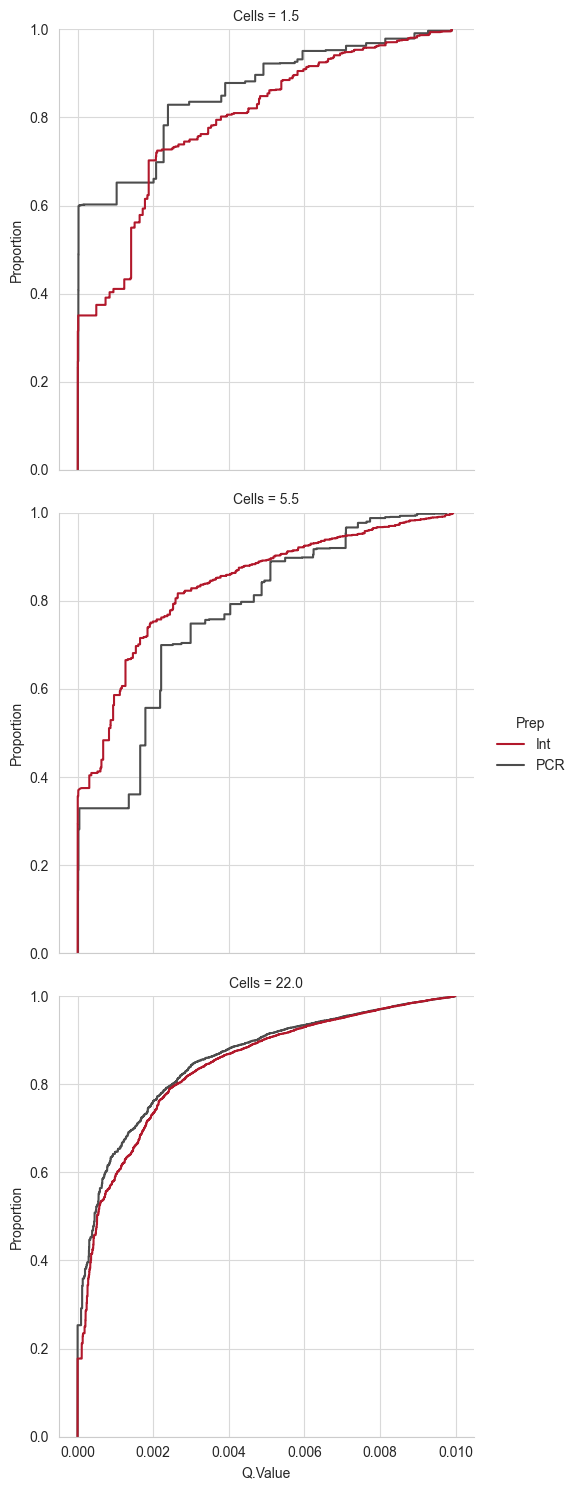

In [19]:
prep_palette = {
    "PCR": '#4d4d4d',
    "Int": '#b2182b'
}
costume_palette = {
    "PCR_22": '#4d4d4d',
    "Int_22": '#b2182b',
    "PCR_5.5": '#999999',
    "Int_5.5": '#ef8a62',
    "PCR_1.5": '#e0e0e0',
    "Int_1.5": '#fddbc7',
}
sns.displot(
    data=KASPAR_MBR[KASPAR_MBR["Prep"] != "Aus"],
    x="Q.Value",
    row="Cells",
    hue="Prep",
    kind="ecdf",
    palette=prep_palette
)

plt.savefig("QValue_ROC.png", dpi = 600)
plt.savefig("QValue_ROC.svg")



In [20]:
KASPAR_stats["Run"] =KASPAR_stats["File.Name"].str.split("\\").str[-1].str.split(".").str[0]
Report = pd.merge(KASPAR_stats, annotation[["Run", "Prep", "Cells", "Replicate"]], on ="Run")
Report["MS1_MS2_SignalRatio"] = Report["MS1.Signal"] / Report["MS2.Signal"]
Report["Condition"] = Report["Prep"] + "_" + Report["Cells"].astype(str)
Report["Experiment"] = Report["Prep"] + "_" + Report["Cells"].astype(str) + "_" + Report["Replicate"].astype(str)
Report = Report[Report["Experiment"]!= "PCR_22.0_R6"]


In [21]:
KASPAR_MBR_stats = []

for i in ["MBR_Int_1.5", "MBR_Int_5.5", "MBR_Int22", "MBR_PCR_1.5", "MBR_PCR_5.5", "MBR_PCR_22"]:
    path = fr"data\MR_SP2_withMBR\{i}\{i}.stats.tsv"
    KASPAR_MBR_stats.append(pd.read_csv(path, sep = "\t"))
KASPAR_MBR_stats = pd.concat(KASPAR_MBR_stats)
KASPAR_MBR_stats["MBR_condition"] = "MBR"

KASPAR_MBR_stats["Run"] =KASPAR_MBR_stats["File.Name"].str.split("\\").str[-1].str.split(".").str[0]
Report_MBR = pd.merge(KASPAR_MBR_stats, annotation[["Run", "Prep", "Cells", "Replicate"]], on ="Run")
Report_MBR["MS1_MS2_SignalRatio"] = Report_MBR["MS1.Signal"] / Report_MBR["MS2.Signal"]
Report_MBR["Condition"] = Report_MBR["Prep"] + "_" + Report_MBR["Cells"].astype(str)
Report_MBR["Experiment"] = Report_MBR["Prep"] + "_" + Report_MBR["Cells"].astype(str) + "_" + Report_MBR["Replicate"].astype(str)

Report_MBR = Report_MBR[Report_MBR["Experiment"]!= "PCR_22.0_R6"]


C:\Users\maldacke\AppData\Local\Temp\14\ipykernel_230196\2208648274.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\maldacke\AppData\Local\Temp\14\ipykernel_230196\2208648274.py:44: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0.75}` instead.

  sns.barplot(
C:\Users\maldacke\AppData\Local\Temp\14\ipykernel_230196\2208648274.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


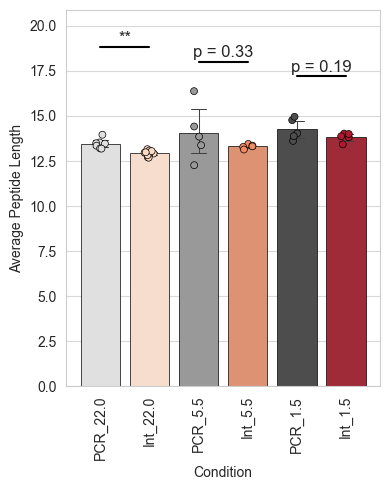

In [22]:
from scipy.stats import mannwhitneyu, ttest_ind, shapiro, levene, fisher_exact

# Define the PCR vs Int pairs
condition_pairs = [
    ("PCR_1.5", "Int_1.5"),
    ("PCR_5.5", "Int_5.5"),
    ("PCR_22.0", "Int_22.0")
]

costume_palette = {
    "PCR_22.0": '#e0e0e0',
    "Int_22.0": '#fddbc7',
    "PCR_5.5": '#999999',
    "Int_5.5": '#ef8a62',
    "PCR_1.5": '#4d4d4d',
    "Int_1.5": '#b2182b',
}
# Function to convert p-value to stars
def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return f"p = {p:.2f}"

# Run t-tests for Average.Peptide.Length
test_results = []
for cond1, cond2 in condition_pairs:
    group1 = Report_MBR[Report_MBR["Condition"] == cond1]["Average.Peptide.Length"]
    group2 = Report_MBR[Report_MBR["Condition"] == cond2]["Average.Peptide.Length"]
    sd_cond1 = Report_MBR[Report_MBR["Condition"] == cond1]["Average.Peptide.Length"].sem()
    sd_cond2 = Report_MBR[Report_MBR["Condition"] == cond2]["Average.Peptide.Length"].sem()
    t_stat, p_val = ttest_ind(group1, group2, equal_var=False)
    test_results.append(((cond1, sd_cond1, cond2,  sd_cond2), p_val))

# --- Plot ---
plt.figure(figsize=(4, 5))
plt.xticks(rotation=90)

# Barplot
sns.barplot(
    data=Report_MBR,
    x="Condition",
    y="Average.Peptide.Length",
    order=condition_order,
    capsize=0.3,
    errwidth=0.75,
    palette=costume_palette,
    edgecolor="black",
    linewidth=0.5
)

# Stripplot with black borders
sns.stripplot(
    data=Report_MBR,
    x="Condition",
    y="Average.Peptide.Length",
    order=condition_order,
    palette=costume_palette,
    edgecolor="black",
    linewidth=0.5
)

# --- Add significance annotations ---
y_max = Report_MBR["Average.Peptide.Length"].max()
y_start = y_max * 1.05
h = y_max * 0.05

for i, (vals, pval) in enumerate(test_results):
    cond1, sd1, cond2, sd2 = vals

    x1, x2 = condition_order.index(cond1), condition_order.index(cond2)
    y = y_start + i * h

    plt.plot([x1, x2], [y, y], color='black')
    plt.text((x1 + x2) / 2, y + h * 0.1, get_star(pval),
             ha='center', va='bottom', fontsize=12)


# Adjust y-axis limit for space
plt.ylim(0, y_start + len(test_results) * h + h * 1.5)

plt.ylabel("Average Peptide Length")
plt.tight_layout()
plt.savefig("Avg_pep_length.png", dpi = 600)
plt.savefig("Avg_pep_length.svg")
plt.show()


In [23]:
display(test_results)

[(('PCR_1.5', 0.26028918533047035, 'Int_1.5', 0.10801046245618995),
  0.19072670110322149),
 (('PCR_5.5', 0.6791182076781627, 'Int_5.5', 0.050492177611982755),
  0.3310312635212654),
 (('PCR_22.0', 0.09821834623640827, 'Int_22.0', 0.04648232579777236),
  0.0011214795602359354)]

In [24]:
Variance = KASPAR_MBR[KASPAR_MBR["Condition"].isin(condition_order)]
Variance = Variance.drop_duplicates(["Experiment", "Precursor.Id"], keep= "first")
Variance.groupby(["Condition", "Precursor.Id"])["Log2_PeptideIntensity"].var()

Condition  Precursor.Id            
Int_1.5    AAATFNPELITHILDGSPENTRR4    0.541813
           AAATTVQEYLK2                0.618307
           AAELIANSLATAGDGLIELRK3      0.668222
           AAEMLLFGK2                  1.585485
           AAFIDNMNQYTR2               0.836893
                                         ...   
PCR_5.5    YYTSASGDEMVSLK2             2.409616
           YYVGIDVGTGSVR2                   NaN
           YYVTIIDAPGHR2                    NaN
           YYVTIIDAPGHR3                    NaN
           YYVTIIDAPGHRDFIK3                NaN
Name: Log2_PeptideIntensity, Length: 74400, dtype: float32

In [25]:

# Step 1: Count valid (non-missing) values per (Condition, Protein)
valid_counts = Variance.groupby(["Condition", "Precursor.Id"])["Log2_PeptideIntensity"].count()

# Step 2: Filter out those with fewer than 2 replicates
valid_proteins = valid_counts[valid_counts >= 3].index

# Step 3: Subset Variance to only valid proteins
filtered_Variance = Variance.set_index(["Condition", "Precursor.Id"])
filtered_Variance = filtered_Variance.loc[filtered_Variance.index.isin(valid_proteins)].reset_index()

# Step 4: Calculate SD and mean per (Condition, Protein)
std_dev = filtered_Variance.groupby(["Condition", "Precursor.Id"])["Log2_PeptideIntensity"].std()
mean_intensity = filtered_Variance.groupby(["Condition", "Precursor.Id"])["Log2_PeptideIntensity"].mean()

# Step 5: Compute coefficient of variation
cv = std_dev / mean_intensity
CV = cv.reset_index()
CV.columns = ["Condition", "Precursor.Id", "CV"]

# Optional: add replicate count if desired
replicate_count = filtered_Variance.groupby(["Condition", "Precursor.Id"])["Log2_PeptideIntensity"].count().reset_index(name="ReplicateCount")
CV = CV.merge(replicate_count, on=["Condition", "Precursor.Id"])



In [26]:
CV.groupby("Condition")["Precursor.Id"].nunique()

Condition
Int_1.5      2774
Int_22.0    29246
Int_5.5      5171
PCR_1.5       566
PCR_22.0    21018
PCR_5.5       462
Name: Precursor.Id, dtype: int64

In [52]:
filtered_Variance

,Condition,Precursor.Id,Run.Index,Run,Channel,Modified.Sequence,Stripped.Sequence,Precursor.Charge,Precursor.Lib.Index,Decoy,...,Best.Fr.Mz,Best.Fr.Mz.Delta,MBR_condition,Unnamed: 0,Prep,Replicate,Cells,Experiment,Log2_ProteinIntensity,Log2_PeptideIntensity
0,Int_1.5,AAATFNPELITHILDGSPENTRR4,2,MAM1496_S1-G3_1_12593,,AAATFNPELITHILDGSPENTRR,AAATFNPELITHILDGSPENTRR,4,0,0,...,974.515991,-0.001953,MBR,25,Int,R3,1.5,Int_1.5_R3,13.077534,11.852812
1,Int_1.5,AAATFNPELITHILDGSPENTRR4,3,MAM1497_S1-G4_1_12595,,AAATFNPELITHILDGSPENTRR,AAATFNPELITHILDGSPENTRR,4,0,0,...,974.515991,0.003662,MBR,26,Int,R4,1.5,Int_1.5_R4,13.559665,13.309984
2,Int_1.5,AAATFNPELITHILDGSPENTRR4,4,MAM1498_S1-G5_1_12596,,AAATFNPELITHILDGSPENTRR,AAATFNPELITHILDGSPENTRR,4,0,0,...,458.733398,0.005981,MBR,27,Int,R5,1.5,Int_1.5_R5,13.905768,12.762852
3,Int_1.5,AAATTVQEYLK2,1,MAM1495_S1-G2_1_12592,,AAATTVQEYLK,AAATTVQEYLK,2,1,0,...,880.477478,-0.000671,MBR,24,Int,R2,1.5,Int_1.5_R2,13.021662,11.535714
4,Int_1.5,AAATTVQEYLK2,2,MAM1496_S1-G3_1_12593,,AAATTVQEYLK,AAATTVQEYLK,2,1,0,...,981.525146,0.000183,MBR,25,Int,R3,1.5,Int_1.5_R3,11.980476,11.581509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389164,PCR_22.0,YYYVAEYK2,2,MAM1129_S3-A9_1_9710,,YYYVAEYK,YYYVAEYK,2,26935,0,...,772.387573,-0.001465,MBR,9,PCR,R3,22.0,PCR_22.0_R3,11.140633,11.656786
389165,PCR_22.0,YYYVAEYK2,3,MAM1130_S3-A10_1_9711,,YYYVAEYK,YYYVAEYK,2,26935,0,...,935.450867,-0.002075,MBR,10,PCR,R4,22.0,PCR_22.0_R4,11.714624,11.006698
389166,PCR_22.0,YYYVAEYK2,4,MAM1131_S3-A11_1_9712,,YYYVAEYK,YYYVAEYK,2,26935,0,...,772.387573,-0.001221,MBR,11,PCR,R5,22.0,PCR_22.0_R5,11.072332,11.409947
389167,PCR_22.0,YYYVAEYK2,6,MAM1360_S2-A11_1_10996,,YYYVAEYK,YYYVAEYK,2,26935,0,...,490.197235,0.000458,MBR,38,PCR,R7,22.0,PCR_22.0_R7,11.687726,10.899442


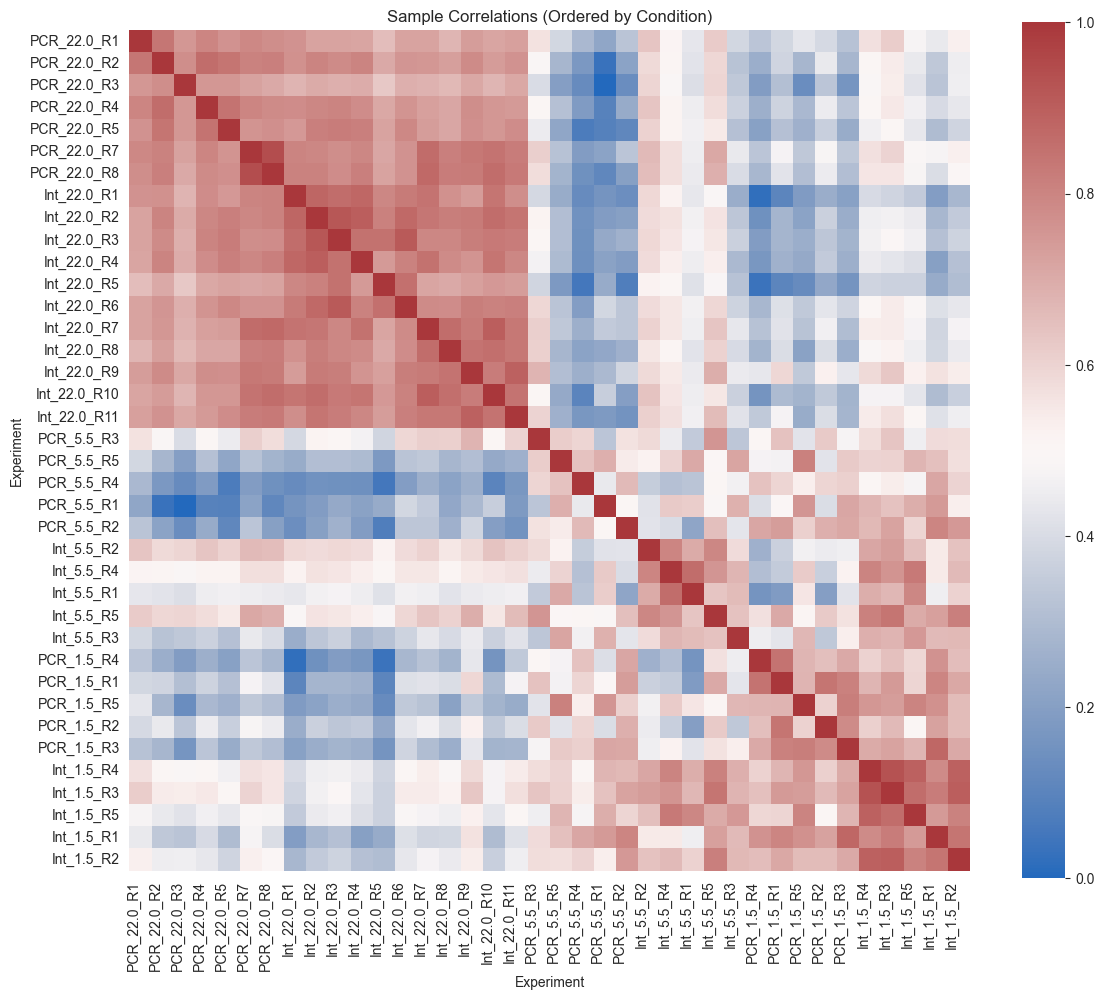

In [59]:
order = ['PCR_22.0_R1', 'PCR_22.0_R2', 'PCR_22.0_R3', 'PCR_22.0_R4', 'PCR_22.0_R5',  'PCR_22.0_R7', 'PCR_22.0_R8',
         'Int_22.0_R1', 'Int_22.0_R2', 'Int_22.0_R3', 'Int_22.0_R4', 'Int_22.0_R5','Int_22.0_R6', 'Int_22.0_R7','Int_22.0_R8','Int_22.0_R9', 'Int_22.0_R10','Int_22.0_R11',
         'PCR_5.5_R3', 'PCR_5.5_R5','PCR_5.5_R4','PCR_5.5_R1','PCR_5.5_R2',
         'Int_5.5_R2', 'Int_5.5_R4','Int_5.5_R1', 'Int_5.5_R5','Int_5.5_R3',
         'PCR_1.5_R4', 'PCR_1.5_R1',   'PCR_1.5_R5', 'PCR_1.5_R2', 'PCR_1.5_R3',
         'Int_1.5_R4', 'Int_1.5_R3', 'Int_1.5_R5','Int_1.5_R1', 'Int_1.5_R2']

precursor_matrix = filtered_Variance.pivot(index = "Precursor.Id", columns = "Experiment", values = "Log2_PeptideIntensity")
precursor_matrix = precursor_matrix.reindex(columns=order)

corr_all = precursor_matrix.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_all, annot=False, cmap='vlag', vmin=0, vmax=1,
            center=0.5, square=True, fmt='.2f')
plt.title('Sample Correlations (Ordered by Condition)')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Correlation_heatmap.svg", dpi = 600)
plt.show()

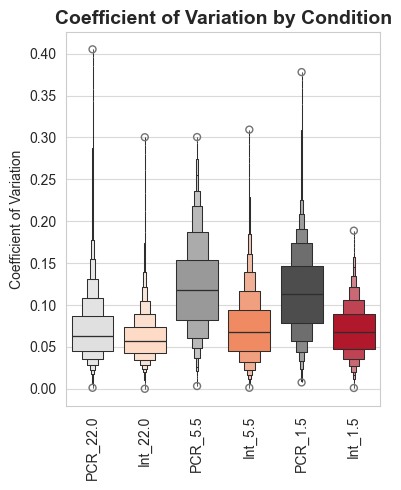


=== Summary of CV values per condition ===
            Mean_CV     SD_CV      N      Mean ± SD
Condition                                          
PCR_22.0   0.070387  0.036190  21018   0.07 ± 0.036
Int_22.0   0.061078  0.026859  29246  0.061 ± 0.027
PCR_5.5    0.122397  0.054835    462  0.122 ± 0.055
Int_5.5    0.073633  0.039679   5171   0.074 ± 0.04
PCR_1.5    0.115849  0.050630    566  0.116 ± 0.051
Int_1.5    0.070549  0.030843   2774  0.071 ± 0.031




In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Step 1: Define plotting order and colors ---
condition_order = ["PCR_22.0", "Int_22.0", "PCR_5.5", "Int_5.5", "PCR_1.5", "Int_1.5"]
costume_palette = {
    "PCR_22.0": '#e0e0e0',
    "Int_22.0": '#fddbc7',
    "PCR_5.5": '#999999',
    "Int_5.5": '#ef8a62',
    "PCR_1.5": '#4d4d4d',
    "Int_1.5": '#b2182b',
}

# --- Step 2: Plot boxenplot ---
plt.figure(figsize=(4, 5))
ax = sns.boxenplot(
    x="Condition",
    y="CV",
    hue="Condition",
    data=CV,
    order=condition_order,
    palette=costume_palette,
    saturation=1,
    k_depth=20
)

plt.xticks(rotation=90)
plt.title('Coefficient of Variation by Condition', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Coefficient of Variation')

plt.tight_layout()
plt.savefig("Variance_boxen.png", dpi=600)
plt.savefig("Variance_boxen.svg", dpi=300)
plt.show()

# --- Step 3: Summary statistics ---
summary = (
    CV.groupby("Condition")["CV"]
    .agg(['mean', 'std', 'count'])
    .reindex(condition_order)
    .rename(columns={'mean': 'Mean_CV', 'std': 'SD_CV', 'count': 'N'})
)

# Format output nicely
summary["Mean ± SD"] = summary["Mean_CV"].round(3).astype(str) + " ± " + summary["SD_CV"].round(3).astype(str)

print("\n=== Summary of CV values per condition ===")
print(summary[["Mean_CV", "SD_CV", "N", "Mean ± SD"]].to_string(index=True))
print("\n")


In [29]:
# Define condition pairs
condition_pairs = [
    ("PCR_22.0", "Int_22.0"),
    ("PCR_5.5", "Int_5.5"),
    ("PCR_1.5", "Int_1.5")
]

results = []

for cond1, cond2 in condition_pairs:
    # Step 1: Get proteins with >=3 valid replicates in EACH condition
    valid_cond1 = Variance[Variance["Condition"] == cond1].groupby("Precursor.Id")["Log2_PeptideIntensity"].count()
    valid_cond1 = valid_cond1[valid_cond1 >= 3].index

    valid_cond2 = Variance[Variance["Condition"] == cond2].groupby("Precursor.Id")["Log2_PeptideIntensity"].count()
    valid_cond2 = valid_cond2[valid_cond2 >= 3].index

    # Step 2: Shared proteins (valid in BOTH)
    shared_proteins = set(valid_cond1) & set(valid_cond2)

    if len(shared_proteins) == 0:
        print(f"No shared proteins with >=3 replicates between {cond1} and {cond2}")
        continue

    # Step 3: Filter data for shared proteins
    data_cond1 = Variance[(Variance["Condition"] == cond1) & (Variance["Precursor.Id"].isin(shared_proteins))]
    data_cond2 = Variance[(Variance["Condition"] == cond2) & (Variance["Precursor.Id"].isin(shared_proteins))]

    # Step 4: Calculate CV (dropna to handle any NaN CVs)
    cv_cond1 = (data_cond1.groupby("Precursor.Id")["Log2_PeptideIntensity"].std() /
                data_cond1.groupby("Precursor.Id")["Log2_PeptideIntensity"].mean()).dropna()
    cv_cond2 = (data_cond2.groupby("Precursor.Id")["Log2_PeptideIntensity"].std() /
                data_cond2.groupby("Precursor.Id")["Log2_PeptideIntensity"].mean()).dropna()

    # Step 5: Store with ACTUAL condition names in columns
    results.append({
        'pair': f"{cond1} vs {cond2}",
        'shared_N': len(shared_proteins),
        f'CV_{cond1}_mean': cv_cond1.mean(),
        f'CV_{cond1}_sd': cv_cond1.std(),
        f'CV_{cond2}_mean': cv_cond2.mean(),
        f'CV_{cond2}_sd': cv_cond2.std()
    })

# Create tidy DataFrame (no pivot needed)
df = pd.DataFrame(results).round(3)
df


,pair,shared_N,CV_PCR_22.0_mean,CV_PCR_22.0_sd,CV_Int_22.0_mean,CV_Int_22.0_sd,CV_PCR_5.5_mean,CV_PCR_5.5_sd,CV_Int_5.5_mean,CV_Int_5.5_sd,CV_PCR_1.5_mean,CV_PCR_1.5_sd,CV_Int_1.5_mean,CV_Int_1.5_sd
0,PCR_22.0 vs Int_22.0,19394,0.069,0.034,0.061,0.026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PCR_5.5 vs Int_5.5,388,NaN,NaN,NaN,NaN,0.129,0.055,0.106,0.054,NaN,NaN,NaN,NaN
2,PCR_1.5 vs Int_1.5,506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.115,0.051,0.075,0.034


In [30]:
KASPAR["Peptide_Lenght"] = KASPAR["Stripped.Sequence"].apply(len)

def count_missed_cleavages(seq):
    return sum(1 for aa in seq[:-1] if aa in ("K", "R"))

KASPAR["MissedCleavages"] = KASPAR["Stripped.Sequence"].apply(count_missed_cleavages)


KASPAR_MBR["Peptide_Lenght"] = KASPAR_MBR["Stripped.Sequence"].apply(len)

def count_missed_cleavages(seq):
    return sum(1 for aa in seq[:-1] if aa in ("K", "R"))

KASPAR_MBR["MissedCleavages"] = KASPAR_MBR["Stripped.Sequence"].apply(count_missed_cleavages)

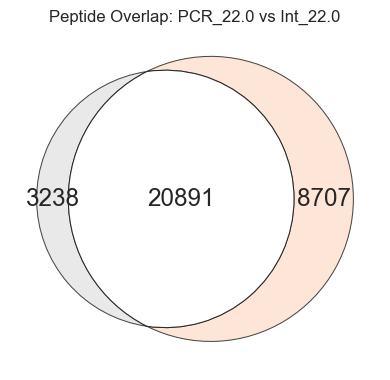

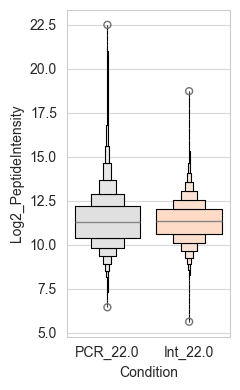

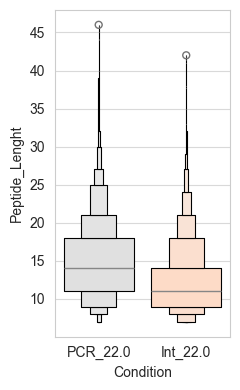

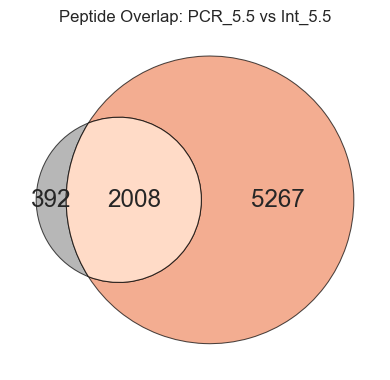

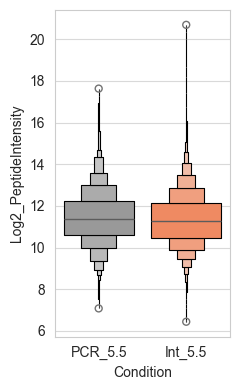

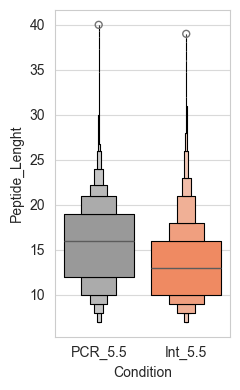

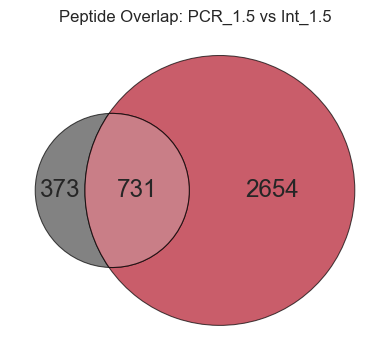

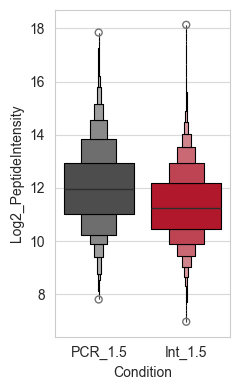

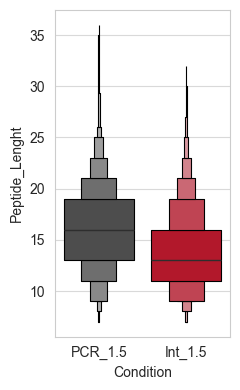


All plots completed successfully.



In [31]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
import pandas as pd
import numpy as np

# --- Colors ---
custom_palette = {
    "PCR_22.0": '#e0e0e0',
    "Int_22.0": '#fddbc7',
    "PCR_5.5": '#999999',
    "Int_5.5": '#ef8a62',
    "PCR_1.5": '#4d4d4d',
    "Int_1.5": '#b2182b',
}

# --- Comparisons ---
comparisons = [["PCR_22.0", "Int_22.0"],
               ["PCR_5.5", "Int_5.5"],
               ["PCR_1.5", "Int_1.5"]]

# --- Group peptides by condition ---
condition_peptides = {
    condition: set(group["Stripped.Sequence"])
    for condition, group in KASPAR_MBR.groupby("Condition")
}

unique_peptides_dict = {}

for cond1, cond2 in comparisons:
    set1 = condition_peptides[cond1]
    set2 = condition_peptides[cond2]
    colors = [custom_palette[cond1], custom_palette[cond2]]

    # --- Venn Plot ---
    plt.figure(figsize=(4, 6))
    v = venn2([set1, set2], set_labels=[" ", " "], set_colors=colors, alpha=0.7)
    for patch_key in ('10', '01', '11'):
        patch = v.get_patch_by_id(patch_key)
        if patch is not None:
            patch.set_edgecolor('black')
            patch.set_linewidth(0.75)
    for text_id in ('10', '01', '11'):
        label = v.get_label_by_id(text_id)
        label.set_fontsize(label.get_fontsize() * 1.75)

    plt.title(f"Peptide Overlap: {cond1} vs {cond2}")
    plt.tight_layout()
    plt.savefig(f"Venn_{cond1}.png", dpi=600)
    plt.savefig(f"Venn_{cond1}.svg")
    plt.show()

    # --- Unique peptides ---
    unique1 = set1 - set2
    unique2 = set2 - set1
    unique_peptides_dict[cond1] = unique1
    unique_peptides_dict[cond2] = unique2

    order = [cond1, cond2]
    plot_palette = {cond1: custom_palette[cond1], cond2: custom_palette[cond2]}

    subset = KASPAR_MBR[
        (KASPAR_MBR["Condition"].isin([cond1, cond2])) &
        (KASPAR_MBR["Stripped.Sequence"].isin(list(unique1) + list(unique2)))
    ]

    # === Boxenplot: Log2_PeptideIntensity ===
    plt.figure(figsize=(2.5, 4))
    ax = sns.boxenplot(
        subset, x="Condition", y="Log2_PeptideIntensity", hue="Condition",
        palette=plot_palette, saturation=1, k_depth=20,
        linewidth=0.8, edgecolor="black", order=order, legend=False
    )

    plt.tight_layout()
    plt.savefig(f"Boxen_unique_intensity_{cond1}.png", dpi=600)
    plt.savefig(f"Boxen_unique_intensity_{cond1}.svg")
    plt.show()

    # === Boxenplot: Peptide Length ===
    plt.figure(figsize=(2.5, 4))
    ax = sns.boxenplot(
        subset, x="Condition", y="Peptide_Lenght", hue="Condition",
        palette=plot_palette, saturation=1, k_depth=20,
        linewidth=0.8, edgecolor="black", order=order, legend=False
    )

    plt.tight_layout()
    plt.savefig(f"Boxen_unique_Length_{cond1}.png", dpi=600)
    plt.savefig(f"Boxen_unique_Length_{cond1}.svg")
    plt.show()

print("\nAll plots completed successfully.\n")


In [31]:
import time
from collections import Counter
from io import StringIO

import pandas as pd
from lxml import etree
from Bio import Entrez
from io import BytesIO
from lxml import etree


In [32]:
PMCs = pd.read_csv("pmid-lasermicro-set.txt", sep = "\t")

In [ ]:


# ===================== USER SETTINGS ==========================================
Entrez.email = "maximilian.maldacker@uniklinik-freiburg.de"  # REQUIRED
Entrez.api_key = None  # optional

PMID_CSV  =None
# ...or directly list a few PMIDs for testing:
PMID_LIST = PMCs["PMIDs"].unique().tolist()  # replace with your own, or leave empty if using CSV

# Output file
OUT_CSV = "lmd_vendor_from_methods_pmc.csv"

# =============================================================================


def load_pmids():
    if PMID_CSV:
        df = pd.read_csv(PMID_CSV)
        if "PMID" not in df.columns:
            raise ValueError("CSV must contain a 'PMID' column.")
        pmids = df["PMID"].astype(str).tolist()
    else:
        pmids = [str(p) for p in PMID_LIST]
    pmids = list(dict.fromkeys(pmids))  # de-duplicate, keep order
    return pmids


def pmid_to_pmcid(pmids):
    """Use Entrez.elink to map PubMed IDs to PMC IDs (if available)."""
    pmcid_map = {}
    for pmid in pmids:
        try:
            handle = Entrez.elink(dbfrom="pubmed", db="pmc", id=pmid, linkname="pubmed_pmc")
            records = Entrez.read(handle)
            handle.close()
            links = records[0].get("LinkSetDb", [])
            if links:
                pmc_ids = [l["Id"] for l in links[0].get("Link", [])]
                if pmc_ids:
                    pmcid_map[pmid] = pmc_ids[0]
        except Exception as e:
            print(f"Warning: elink failed for PMID {pmid}: {e}")
        time.sleep(0.34)
    return pmcid_map


def fetch_pmc_xml(pmcid):
    """Download full PMC XML for one article as bytes."""
    handle = Entrez.efetch(db="pmc", id=pmcid, rettype="full", retmode="xml")
    xml_bytes = handle.read()  # this is already bytes
    handle.close()
    return xml_bytes



def extract_methods_text(xml_bytes):
    """
    Extract Methods / Materials and Methods sections from PMC XML bytes.
    Returns concatenated plain text (possibly empty string if not found).
    """
    # xml_bytes is a bytes object from efetch
    parser = etree.XMLParser(recover=True)
    root = etree.parse(BytesIO(xml_bytes), parser)

    namespace = root.getroot().nsmap.get(None, "")
    ns = {"ns": namespace} if namespace else {}

    # Find all <sec> elements
    secs = root.findall(".//ns:sec" if ns else ".//sec", namespaces=ns)

    methods_chunks = []

    for sec in secs:
        # Get section title text
        title_el = sec.find("ns:title" if ns else "title", namespaces=ns)
        if title_el is not None:
            title = "".join(title_el.itertext()).strip().lower()
        else:
            title = ""

        # Heuristic: methods-like section
        if any(key in title for key in ["methods", "materials and methods", "experimental"]):
            # join all paragraph text within this section
            text = " ".join(
                " ".join(p.itertext())
                for p in sec.findall(".//ns:p" if ns else ".//p", namespaces=ns)
            )
            if text:
                methods_chunks.append(text)

    return "\n\n".join(methods_chunks)



def classify_vendor_from_text(text):
    """Classify vendor using Methods text."""
    t = text.lower()

    # ZEISS PALM
    if ("palm microbeam" in t) or ("palm micro beam" in t) or ("palmmicrobeam" in t):
        return "ZEISS PALM"
    if "zeiss palm" in t or "palm laser microdissection" in t or "palm microdissection" in t:
        return "ZEISS PALM"

    # Leica LMD
    if "leica lmd" in t or "lmd7000" in t or "lmd7" in t or "lmd6" in t:
        return "Leica LMD"
    if "leica microsystems" in t and "microdissection" in t:
        return "Leica LMD"

    # MMI
    if "mmi cellcut" in t or "mmi cell cut" in t:
        return "MMI CellCut"
    if "molecular machines and industries" in t:
        return "MMI CellCut"
    if "caplift" in t:
        return "MMI CellCut"

    # Arcturus / Thermo
    if "arcturusxt" in t or "arcturus xt" in t:
        return "Thermo/Arcturus"
    if "pixcell" in t:
        return "Thermo/Arcturus"
    if "veritas" in t and "laser capture" in t:
        return "Thermo/Arcturus"
    if "arcturus" in t and "laser capture" in t:
        return "Thermo/Arcturus"

    return "Other/Unspecified"


def main():
    print("Loading PMIDs ...")
    pmids = load_pmids()
    print(f"Total PMIDs: {len(pmids)}")

    print("Mapping PMIDs to PMC IDs ...")
    pmcid_map = pmid_to_pmcid(pmids)
    print(f"PMIDs with PMC full text: {len(pmcid_map)}")

    rows = []
    for pmid in pmids:
        pmcid = pmcid_map.get(pmid)
        if not pmcid:
            # no PMC full text
            rows.append({
                "PMID": pmid,
                "PMC_ID": None,
                "Vendor": "No PMC full text",
                "Methods_Text_Short": ""
            })
            continue

        try:
            xml_bytes = fetch_pmc_xml(pmcid)
            methods_text = extract_methods_text(xml_bytes)
            vendor = classify_vendor_from_text(methods_text)
            short = methods_text[:500].replace("\n", " ")
        except Exception as e:
            print(f"Warning: failed for PMID {pmid}, PMC {pmcid}: {e}")
            vendor = "Error"
            short = ""

        rows.append({
            "PMID": pmid,
            "PMC_ID": pmcid,
            "Vendor": vendor,
            "Methods_Text_Short": short
        })
        time.sleep(0.34)

    df = pd.DataFrame(rows)
    df.to_csv(OUT_CSV, index=False)
    print(f"Saved results to {OUT_CSV}")

    # Summary of vendor counts, excluding "No PMC full text" and "Error"
    mask = df["Vendor"].isin(["No PMC full text", "Error"])
    counts = Counter(df.loc[~mask, "Vendor"])
    print("Vendor counts (PMC full-text, Methods-based):")
    for v, n in counts.items():
        print(f"  {v}: {n}")


if __name__ == "__main__":
    main()


Loading PMIDs ...
Total PMIDs: 958
Mapping PMIDs to PMC IDs ...


In [ ]:
meta = pd.read_csv("lmd_vendor_from_methods_pmc.csv")
sns.barplot(data = meta[~meta["Vendor"].isin(["Error","Other/Unspecified", "No PMC full text"])].groupby("Vendor")["PMC_ID"].count(), order = ["Leica LMD", "ZEISS PALM", "MMI CellCut", "Thermo/Arcturus"])
plt.xticks(rotation=90)
plt.savefig(r"Citations.svg")

In [ ]:
empty = pq.read_table(r"data\CarryOver_controls_report.parquet")
empty = empty.to_pandas()
empty

In [ ]:
empty_stats = pd.read_csv(r"data\CarryOver_controls_report.stats.tsv", sep = "\t")
KAPSPAR_stats = pd.read_csv(r"data\Report_nonMBR.stats.tsv", sep = "\t")

Stats = pd.concat([empty_stats, KAPSPAR_stats])

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Add run type column to Stats
Stats['Run.Type'] = Stats['File.Name'].str.contains('CarryOver_controls|empty', case=False).map({True: 'Empty', False: 'Experimental'})

plt.figure(figsize=(8, 6))
sns.boxplot(data=Stats, x='Run.Type', y='Precursors.Identified', color='royalblue')
sns.stripplot(data=Stats, x='Run.Type', y='Precursors.Identified', color='red', alpha=0.6, size=4)
plt.axhline(0, color='black', lw=0.5, linestyle='--')
empty_median = Stats[Stats['Run.Type']=='Empty']['Precursors.Identified'].median()
plt.text(0, empty_median + 50, f'Empty median: {empty_median}', ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='white'))
plt.ylabel('Precursors Identified')
plt.title('Precursors: Empty vs. Experimental Runs')
plt.ylim(-10, Stats['Precursors.Identified'].max() * 1.05)  # Slight padding
plt.tight_layout()
plt.savefig("Identifications_CarryOverRuns.svg")
plt.show()


In [ ]:
Stats['log_MS1'] = np.log10(Stats['MS1.Signal'])  # log(1+x) for zeros
sns.boxplot(data=Stats, x='Run.Type', y='log_MS1')
sns.stripplot(data=Stats, x='Run.Type', y='log_MS1', color='red', alpha=0.6, size=4)
plt.title('Log MS1 Signal: Empty vs Experimental')
plt.savefig("Log10_Intensity_CarryOverRuns.svg")
plt.show()


In [ ]:
import os
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def read_bruker_data(d_folder):
    tdf_path = os.path.join(d_folder, "analysis.tdf")
    conn = sqlite3.connect(tdf_path)
    frames_df = pd.read_sql_query("SELECT Id, Time, MsMsType, SummedIntensities FROM Frames", conn)
    conn.close()

    frames = frames_df.to_numpy()
    rt = frames[:, 1] / 60.0  # Convert to minutes
    ms_type = frames[:, 2]
    total_intensity = frames[:, 3]

    ms1_mask = (ms_type == 0)
    ms2_mask = np.isin(ms_type, [8, 9])
    return rt, total_intensity, ms1_mask, ms2_mask

# Create subplots for all three empty runs
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

samples = ["Maxiempty1_S1-F1_1_17102", "Maxiempty2_S1-F2_1_17103", "Maxiempty3_S1-F3_1_17104"]
base_path = r"D:\data\maldacke\Maxi_empty_ST"

for i, (sample_name, ax) in enumerate(zip(samples, axes)):
    folder_path = os.path.join(base_path, f"{sample_name}.d")

    if os.path.exists(folder_path):
        rt, total_intensity, ms1_mask, ms2_mask = read_bruker_data(folder_path)

        if np.any(ms1_mask):
            ax.plot(rt[ms1_mask], total_intensity[ms1_mask], label='MS1', color='royalblue')
        if np.any(ms2_mask):
            ax.plot(rt[ms2_mask], total_intensity[ms2_mask], label='MS2/DIA', alpha=0.7, color='orange')

        ax.set_ylabel("Intensity")
        ax.set_title(sample_name, fontsize=12)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
    else:
        ax.text(0.5, 0.5, f'Path not found:\n{folder_path}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(sample_name, fontsize=12)

axes[-1].set_xlabel("Retention Time (min)")
plt.tight_layout()

# Save as SVG
svg_path = "TIC_summary.svg"
plt.savefig(svg_path, format='svg', bbox_inches='tight', dpi=300)
print(f"Saved TIC summary to {svg_path}")
plt.show()
